# Does 401(k) eligibility raise wealth? Four estimators, one answer

## Background

The question: does being **eligible** for a 401(k) plan increase a household's net financial assets? This is a classic causal inference problem (it is the running example in Wooldridge's econometrics textbook), and it is hard for one reason: **confounding**. Workers who are offered a 401(k) tend to be richer, older, and more educated than workers who are not. So if we just compare average wealth between the two groups, we mix up the effect of the 401(k) with the effect of being the kind of person who gets offered one.

## Setup (the data)

The data here are **simulated with a known true effect of $8,000** (the classic Wooldridge 401k file could not be fetched; see `data/build_data.py` for the documented data-generating process). That is the point of the exercise: with the truth known, we can measure each method's **bias** and check whether its confidence interval actually covers the truth, which is impossible with real observational data.

The file is `data/401k_simulated.csv`: n = 8,000 workers, eligibility rate 0.769, seven confounders (income, age, education, family size, married, has IRA, owns home). Everything is committed, so this notebook reruns from the repo: Python 3 with numpy, pandas, scikit-learn, scipy, matplotlib, plus `src/` (estimators) and `data/`.

## Method

This notebook compares four estimators of the causal effect:

1. **Naive OLS** (wealth on eligibility, no controls): ignores confounding.
2. **OLS with controls** (adds income, age, education, ...): assumes the confounders enter *linearly*.
3. **Propensity-score matching**: pairs each eligible worker with a similar non-eligible worker.
4. **Double machine learning (DML)**: lets flexible models learn the confounding, then compares what is left.

### How each estimator works

**Naive OLS** regresses wealth on eligibility alone. It attributes all of the wealth gap to the 401(k), including the part that is really income, age, and education. Expect a large upward bias.

**OLS with controls** adds the confounders, but forces them to enter the model as straight lines. In our data the income effect on wealth is *concave* (diminishing returns: the first $20k of income builds more wealth than the next $20k). A straight line cannot follow a curve, so some income confounding leaks through into the eligibility coefficient. Expect a smaller but still positive bias.

**Propensity-score matching** first estimates each worker's probability of being eligible (the propensity score, via logistic regression), then pairs each eligible worker with the non-eligible worker with the closest score, reusing controls when the control pool is small. If the pairs are truly alike on all confounders, the average within-pair wealth difference estimates the effect on the treated. We check balance with standardized mean differences before and after matching.

**Double machine learning** works in three steps. (1) Split the sample into K folds. (2) On each fold, use the *other* folds to train a flexible model of wealth given X and a flexible model of eligibility given X, then predict out-of-fold. (3) Regress the wealth residuals on the eligibility residuals. The intuition: after removing everything about wealth and eligibility that the confounders can explain, whatever co-movement is left is the causal effect. Cross-fitting (predicting out-of-fold) keeps the machine learning models honest so they cannot overfit the noise and smuggle it into the estimate. Standard errors come from the residual regression and are robust to heteroskedasticity.

In [1]:
import sys, json
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from estimators import naive_ols, ols_controls, propensity_match, dml, rf_learner, gbm_learner

SEED = 20261002
TRUTH = 8000.0
COLS = ["inc", "age", "educ", "fsize", "marr", "pira", "hown"]
LABELS = {"inc": "Income ($)", "age": "Age", "educ": "Education (yrs)",
          "fsize": "Family size", "marr": "Married", "pira": "Has IRA", "hown": "Owns home"}

df = pd.read_csv("../data/401k_simulated.csv")
y = df["nettfa"].values
d = df["elig401k"].values
x = df[COLS].values
print(f"n = {len(df):,}, eligibility rate = {d.mean():.3f}, true effect = ${TRUTH:,.0f}")

n = 8,000, eligibility rate = 0.769, true effect = $8,000


## Results

### Why the naive comparison fails

Before any estimation, look at the selection mechanism. If eligibility were assigned at random, the eligible and non-eligible groups would look alike. They do not:

In [2]:
tab = df.groupby("elig401k")[COLS + ["nettfa"]].mean().T
tab.columns = ["Not eligible", "Eligible"]
tab["Difference"] = tab["Eligible"] - tab["Not eligible"]
print(tab.round(0).to_string())
print()
print(f"Correlation between income and eligibility: {np.corrcoef(df['inc'], d)[0,1]:.3f}")

        Not eligible  Eligible  Difference
inc          46439.0   79209.0     32770.0
age             43.0      45.0         3.0
educ            14.0      14.0         0.0
fsize            3.0       3.0         0.0
marr             1.0       1.0         0.0
pira             0.0       0.0         0.0
hown             1.0       1.0         0.0
nettfa       70466.0  133550.0     63085.0

Correlation between income and eligibility: 0.294


Eligible workers earn far more, are older, and are more educated. The two groups differ on *every* variable that also drives wealth. A raw difference in means therefore answers the wrong question: it tells us that eligible workers are richer, not that eligibility *made* them richer.

The plot below makes the confounding concrete. Eligibility rises steeply with income, and the income distributions of the two groups barely overlap at the top end:

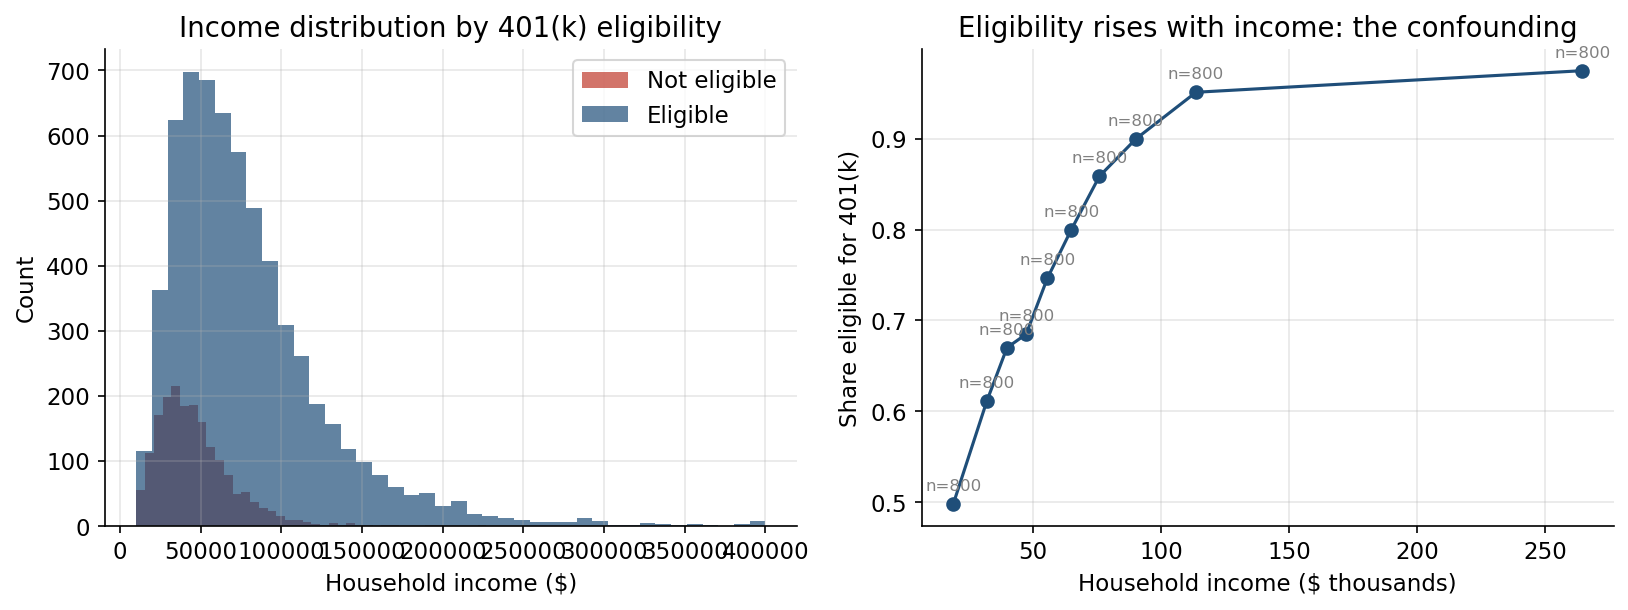

In [3]:
from IPython.display import Image
Image("../figures/confounding.png")

In [4]:
r1 = naive_ols(y, d)
r2 = ols_controls(y, d, x)
r3 = propensity_match(y, d, x, COLS)
r4 = dml(y, d, x, rf_learner(), rf_learner(), n_splits=5, seed=SEED)

rows = []
for name, r in [("Naive OLS", r1), ("OLS with controls", r2),
               ("Propensity-score matching", r3),
               ("DML (K=5, random forest)", r4)]:
    bias = r["estimate"] - TRUTH
    rows.append({"Method": name, "Estimate": round(r["estimate"]),
                 "95% CI": f"[{r['ci_low']:,.0f}, {r['ci_high']:,.0f}]",
                 "Bias": round(bias), "Covers truth": r["ci_low"] <= TRUTH <= r["ci_high"]})
pd.DataFrame(rows).set_index("Method")

,Estimate,95% CI,Bias,Covers truth
Method,,,,
Naive OLS,63085,"[59,621, 66,549]",55085,False
OLS with controls,11542,"[9,006, 14,077]",3542,False
Propensity-score matching,6287,"[4,536, 8,039]",-1713,True
"DML (K=5, random forest)",7768,"[5,210, 10,326]",-232,True


### What the numbers say

The naive estimate is roughly **seven times** the true effect: it credits the 401(k) for wealth that is really explained by higher income. Adding linear controls removes most of the bias but leaves a few thousand dollars of it, because the concave income effect is not a straight line. Matching and DML both get close to the truth and their intervals cover it.

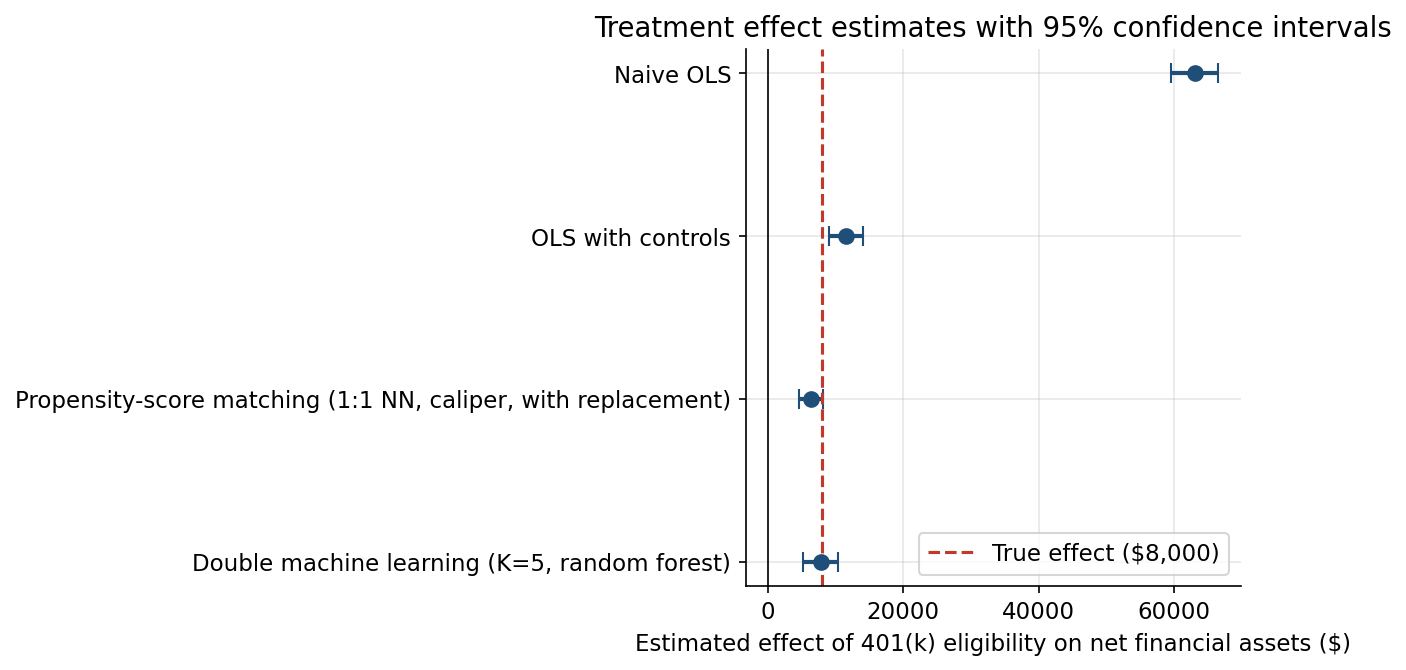

In [5]:
Image("../figures/forest_plot.png")

### Did matching actually balance the groups?

Matching is only as good as the balance it achieves. The standard check is the standardized mean difference (difference in means divided by pooled standard deviation) for each covariate, before and after matching. Values below 0.1 are the usual rule of thumb for "well balanced".

One detail worth knowing: the control pool here is small (about 23% of the sample), so matching *without* replacement would exhaust the good controls and leave income badly imbalanced. Matching *with* replacement (controls may be reused) plus a caliper fixes this:

                 SMD before  SMD after
Income ($)            0.843     -0.001
Age                   0.234     -0.051
Education (yrs)       0.169      0.013
Family size           0.006      0.061
Married               0.200      0.039
Has IRA               0.267      0.056
Owns home             0.099     -0.027

Matched pairs: 6,156, treated dropped by caliper: 0


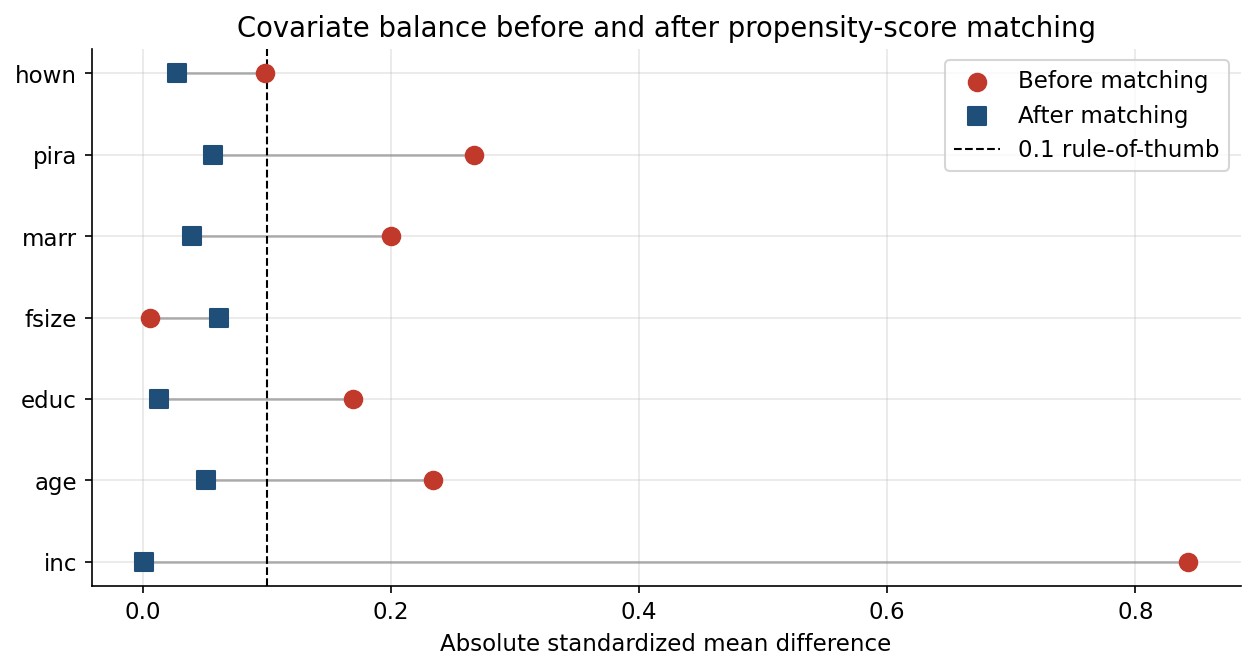

In [6]:
bal = pd.DataFrame(r3["extra"]["balance"]).T.rename(columns={"before": "SMD before", "after": "SMD after"})
bal.index = [LABELS.get(i, i) for i in bal.index]
print(bal.round(3).to_string())
print()
print(f"Matched pairs: {r3['extra']['n_matched_pairs']:,}, treated dropped by caliper: {r3['extra']['n_treated_dropped']}")
Image("../figures/balance_plot.png")

### How sensitive is DML to our choices?

DML has two tuning choices: which machine learning method learns the nuisance functions, and how many folds to use. If the answer moves a lot when we change them, we should not trust it. Here it does not:

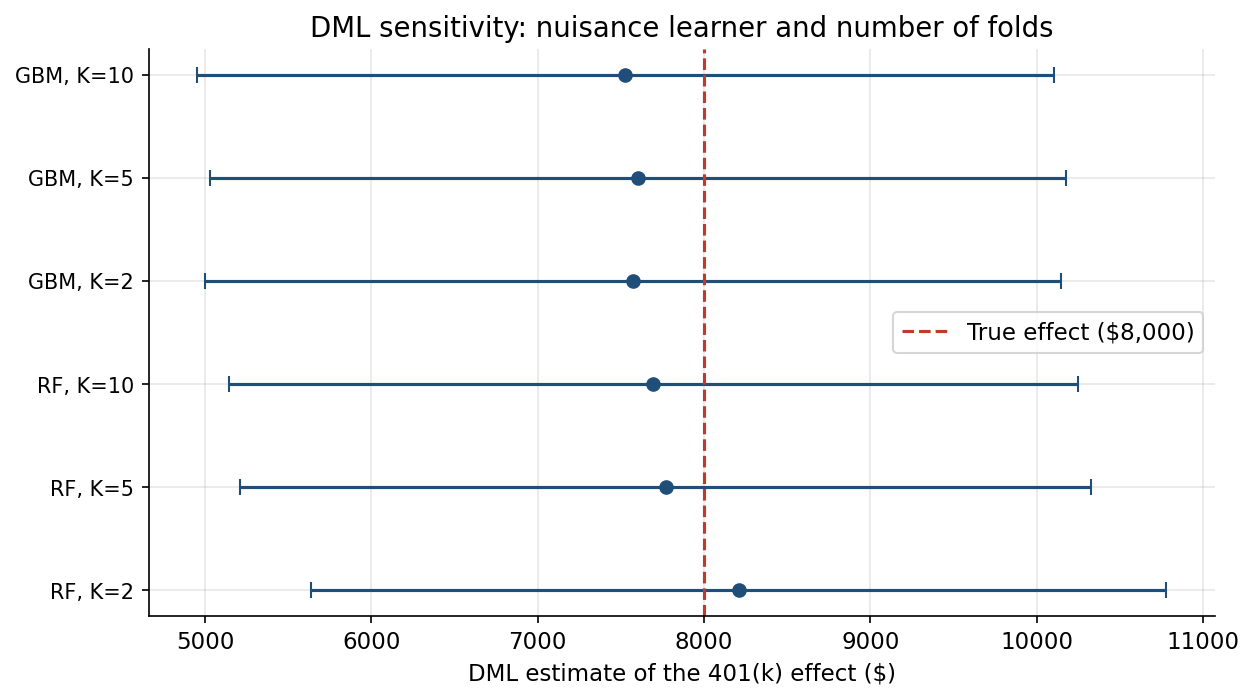

In [7]:
sens = []
for lab, mk in [("RF", rf_learner), ("GBM", gbm_learner)]:
    for k in (2, 5, 10):
        r = dml(y, d, x, mk(SEED), mk(SEED), n_splits=k, seed=SEED)
        sens.append({"Config": f"{lab}, K={k}", "Estimate": round(r["estimate"]),
                     "95% CI": f"[{r['ci_low']:,.0f}, {r['ci_high']:,.0f}]"})
pd.DataFrame(sens).set_index("Config")
Image("../figures/sensitivity.png")

All six configurations land within a few hundred dollars of each other and every interval covers the true $8,000. The conclusion does not depend on the learner or the number of folds.

### A Monte Carlo check: bias and coverage

One dataset gives one draw, so "coverage" from a single interval is anecdotal. To check properly, we repeat the whole exercise on 30 fresh simulated datasets (n = 4,000 each, same data-generating process) and record each method's average bias, how often its 95% interval covers the true $8,000, and the average interval width. A well-calibrated method should cover about 95% of the time.

In [8]:
mc = json.load(open("../data/mc_results.json"))
mc_df = pd.DataFrame(mc).set_index("Method")
mc_df["Mean bias ($)"] = mc_df["Mean bias ($)"].round(0)
mc_df["Mean CI width ($)"] = mc_df["Mean CI width ($)"].round(0)
mc_df["Coverage of 95% CI"] = mc_df["Coverage of 95% CI"].round(2)
mc_df

,Mean bias ($),Coverage of 95% CI,Mean CI width ($)
Method,,,
Naive OLS,56405.0,0.00,9889.0
OLS with controls,4246.0,0.30,7182.0
Propensity-score matching,623.0,0.43,4744.0
"DML (K=5, random forest)",811.0,0.90,7358.0


## Takeaway

**Takeaways.** Confounding is not a technicality here; it is most of the naive estimate. Linear controls help a lot but misspecification of the functional form leaves real bias. Matching works when it achieves balance (check it, do not assume it). DML with cross-fitting removes the confounding without requiring us to guess the right functional form, and it is stable across learners and fold counts.

**Limits.** Every method here assumes *unconfoundedness*: that we measured all the variables that drive both eligibility and wealth. If something unmeasured (say, financial literacy, or working for a generous employer) affects both, all four estimates are biased and no statistical method on these data can fix that. Matching and DML also assume *overlap*: every type of worker must have some chance of being eligible or not, which holds in this simulation by construction. Finally, this is simulated data. The methods are real and the comparison is honest, but the numbers describe the simulation, not the US labor market.